# Electron Diffraction Pattern Processing Tutorial

## Overview

This notebook demonstrates various methods for processing and reconstructing 4D-STEM diffraction data into high-quality 2D powder diffraction patterns. We'll explore:

1. **Raw Summation** (baseline)
2. **Richardson-Lucy Deconvolution**
3. **GMM (Gaussian Mixture Model) Segmentation**
4. **Polar Coordinate Segmentation** (Row Thresholding)
5. **Blob Detection** (Peak Finding)
6. **UNet Neural Network Segmentation**

### Key Findings from Development:
- **GMM fitting**: First method to show improvement over raw deconvolution
- **Row Thresholding**: Worked "incredibly well" - fast and robust
- **Blob Detection (DoH)**: Best overall results when using opening background subtraction

---

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import stemdiff as sd
import ediff.io
import dbase
from reconstruct import sum_datafiles # Main processing function
from utilities import (
    DiffractionPeakSegmenter,    # For polar coordinate segmentation
    DiffractionPeakFinder,       # For blob detection
    UnetSegmenter                # For neural network segmentation
)

# Set up plotting parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 2. Load Your Data

First, set up your data paths and load the database of diffraction patterns.

In [2]:
# === CONFIGURE YOUR PATHS HERE ===
img_path = r"C:\Users\drend\OneDrive\Plocha\VU\1_AU\1_AU\DATA"
df_path = r"C:\Users\drend\OneDrive\Plocha\VU\1_AU\1_AU\DATA\resultsdbase_sum.zip"
psf_path = r"C:\Users\drend\OneDrive\Plocha\VU\1_AU\1_AU\DATA\resultspsf.npy"  # Optional: for deconvolution methods

# Load the database
df_sum = dbase.read_database(df_path)
print(f"Loaded database with {len(df_sum)} diffraction patterns")
print(f"Database columns: {df_sum.columns.tolist()}")

# Set up source data
SDATA = sd.gvars.SourceData(
    detector=sd.detectors.TimePix(),
    data_dir=img_path,
    filenames=r'*.dat'
)

# Set up diffraction images parameters
DIFFIMAGES = sd.gvars.DiffImages()

print(f"Image size: {DIFFIMAGES.imgsize}")
print(f"Detector upscale: {SDATA.detector.upscale}")

Loaded database with 200 diffraction patterns
Database columns: ['DatafileName', 'Xcenter', 'Ycenter', 'MaxInt', 'Peaks', 'S']
Image size: 100
Detector upscale: 4


## 3. Method 1: Raw Summation (Baseline)

The simplest approach - just sum all diffraction patterns without any processing.

**Use case**: Quick baseline for comparison

Processing :   0%|          | 0/200 [00:00<?, ?it/s](400, 400)
(400, 400)
Processing :   1%|          | 2/200 [00:00<00:11, 17.46it/s](400, 400)
(400, 400)
Processing :   2%|▏         | 4/200 [00:00<00:11, 17.71it/s](400, 400)
(400, 400)
Processing :   3%|▎         | 6/200 [00:00<00:10, 17.81it/s](400, 400)
(400, 400)
Processing :   4%|▍         | 8/200 [00:00<00:11, 17.13it/s](400, 400)
(400, 400)
Processing :   5%|▌         | 10/200 [00:00<00:10, 17.37it/s](400, 400)
(400, 400)
Processing :   6%|▌         | 12/200 [00:00<00:10, 17.45it/s](400, 400)
(400, 400)
Processing :   7%|▋         | 14/200 [00:00<00:10, 17.55it/s](400, 400)
(400, 400)
Processing :   8%|▊         | 16/200 [00:00<00:10, 17.67it/s](400, 400)
(400, 400)
Processing :   9%|▉         | 18/200 [00:01<00:10, 17.74it/s](400, 400)
(400, 400)
Processing :  10%|█         | 20/200 [00:01<00:10, 17.65it/s](400, 400)
(400, 400)
Processing :  11%|█         | 22/200 [00:01<00:10, 17.71it/s](400, 400)
(400, 400)
Processing :  12%

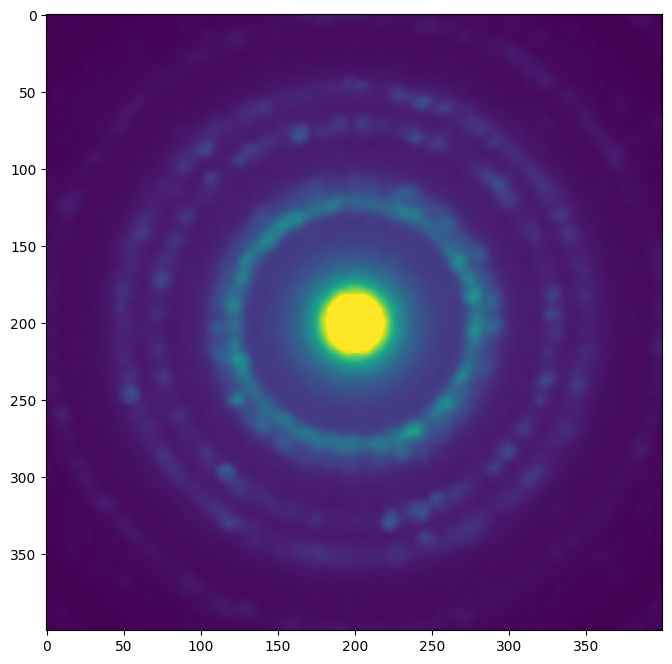

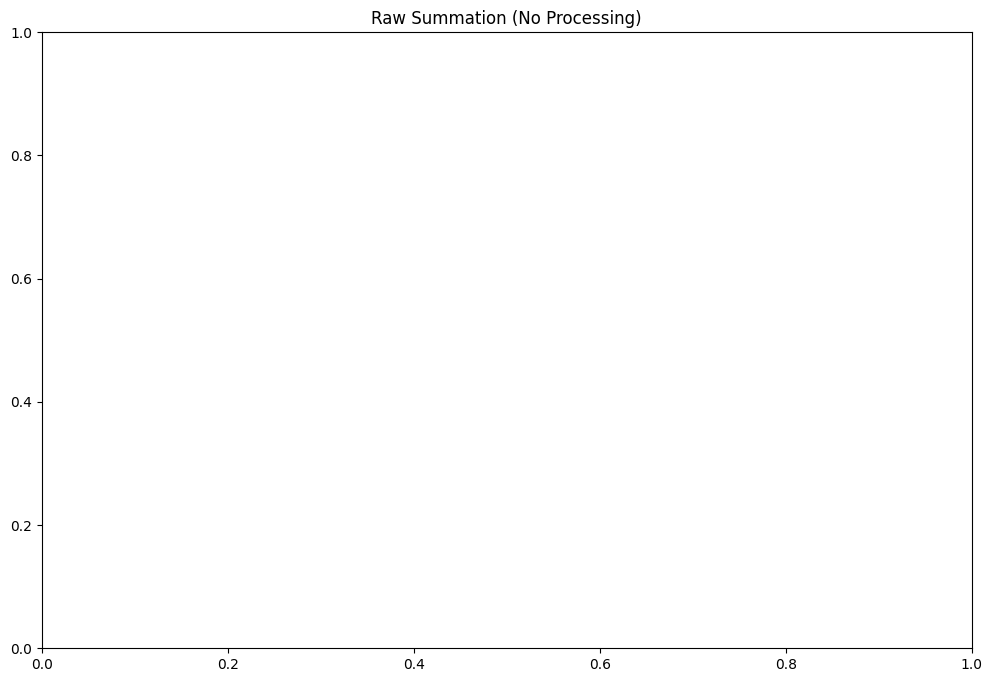

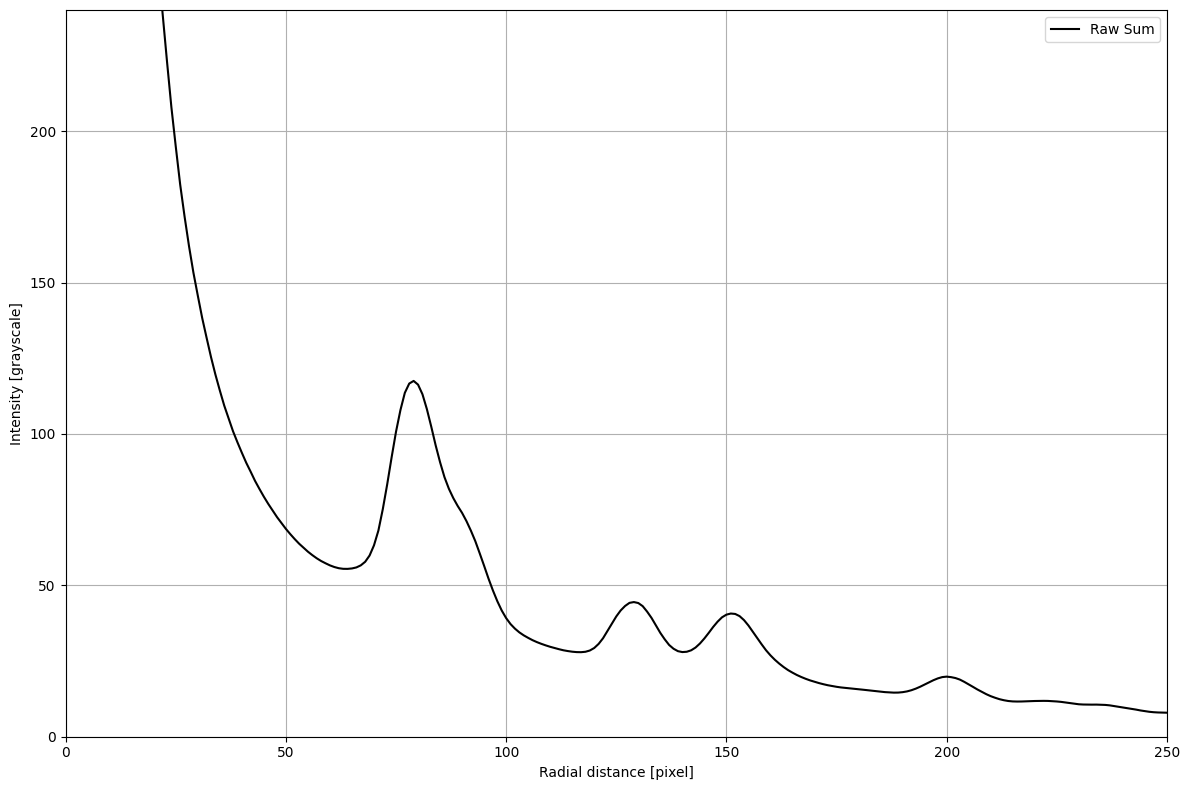

In [4]:
# Raw summation - no parameters needed!
sum_data_raw = sum_datafiles(
    SDATA, 
    DIFFIMAGES, 
    df_sum, 
    method='raw_sum'
)

# Visualize
sd.io.Arrays.show(sum_data_raw, icut=300)
plt.title('Raw Summation (No Processing)')
plt.show()

# Calculate radial profile
import ediff as ed
ed.io.plot_radial_distributions(
    data_to_plot=[[sum_data_raw, 'k-', 'Raw Sum']], 
    xlimit=250, 
    ylimit=240
)

## 4. Method 2: Richardson-Lucy Deconvolution

Deconvolves using a Point Spread Function (PSF) to sharpen peaks.

### Parameters:
- `psf`: Pre-calculated PSF (numpy array)
- `iterate`: Number of iterations (default: 10)
- `regularization`: 'TM' (Tikhonov), 'TV' (Total Variation), or None
- `lambda_reg`: Regularization strength (default: 1)

**Note**: Slower than other methods, especially with regularization. Often doesn't improve results significantly.

Processing : 100%|██████████| 200/200 [00:41<00:00,  4.81it/s]



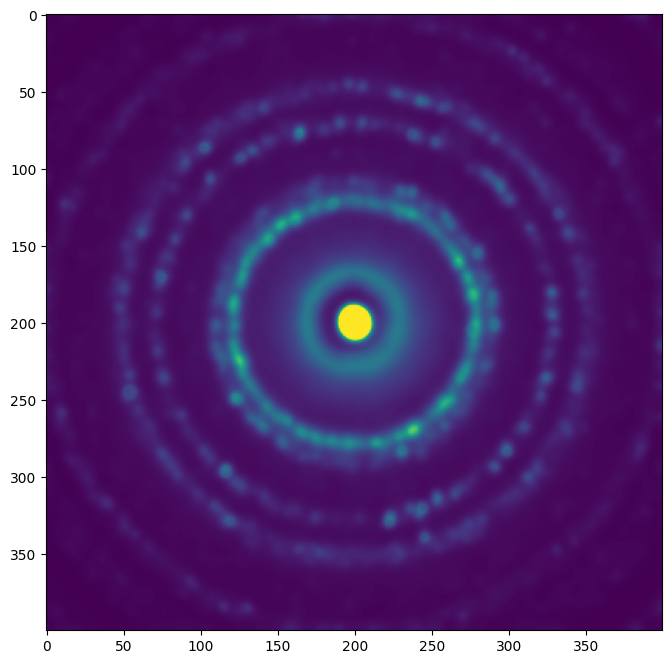

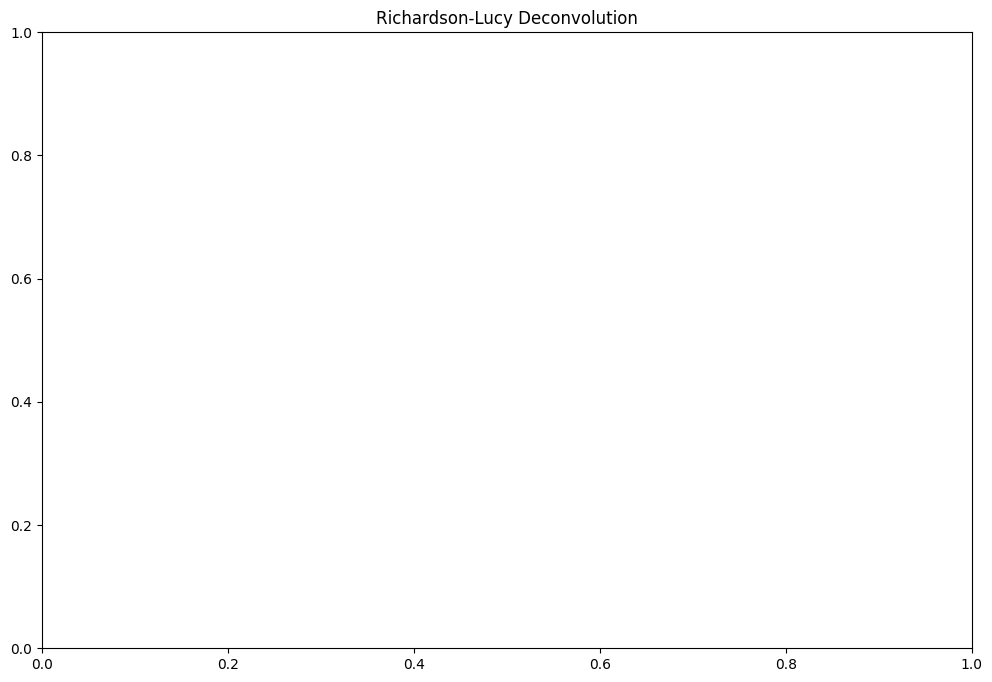

In [5]:
# Load and prepare PSF
psf = np.load(psf_path)

# Crop and threshold PSF (optional but recommended)
psf = psf[30:90, 30:90]
flat_psf = psf.flatten()
num_elements_to_set_zero = int(0.6 * flat_psf.size)
threshold_value = np.partition(flat_psf, num_elements_to_set_zero)[num_elements_to_set_zero]
mask = psf <= threshold_value
psf[mask] = 0

# Run deconvolution
sum_data_deconv = sum_datafiles(
    SDATA, 
    DIFFIMAGES, 
    df_sum,
    method='RL_global_psf',
    psf=psf,
    iterate=10,
    regularization=None  # Try 'TM' or 'TV' if needed
)

sd.io.Arrays.show(sum_data_deconv, icut=300)
plt.title('Richardson-Lucy Deconvolution')
plt.show()

## 5. Method 3: GMM (Gaussian Mixture Model) Segmentation

Fits a 3-component GMM (peaks, noise, background) to segment peaks.

### Parameters:
None required! Uses automatic segmentation.

**Pros**: 
- First method that significantly improved over deconvolution
- No parameter tuning needed
- Works well on most datasets

**Cons**:
- Can be sensitive to image contrast
- May miss weak peaks

Processing : 100%|██████████| 200/200 [02:33<00:00,  1.31it/s]



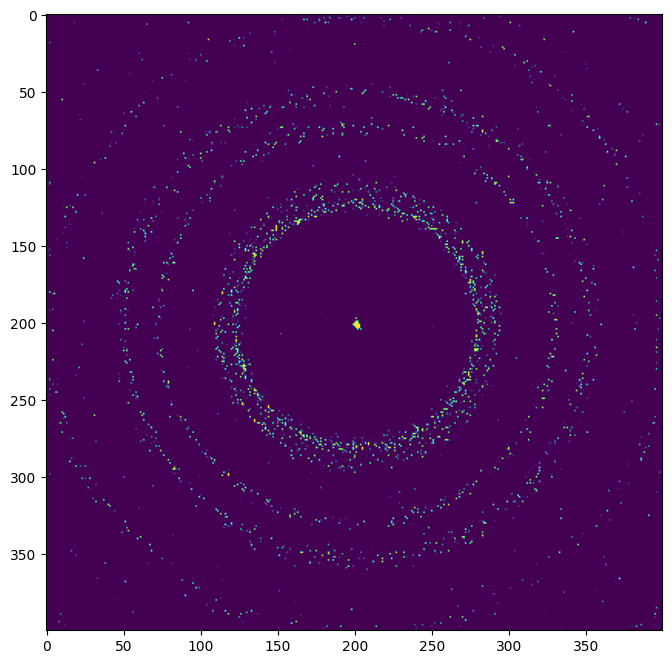

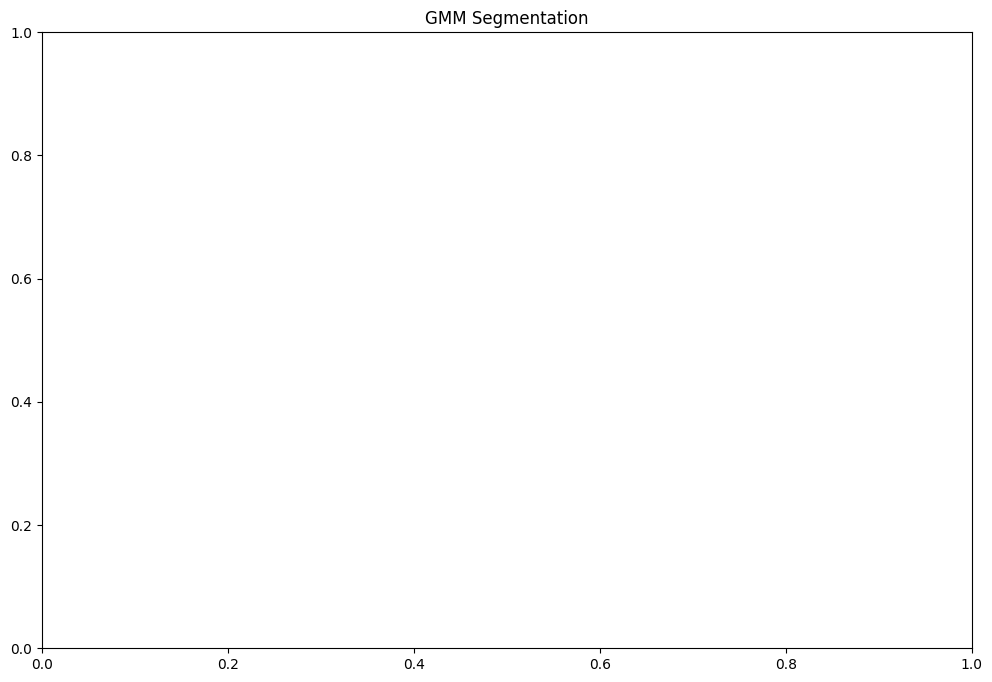

In [6]:
sum_data_gmm = sum_datafiles(
    SDATA, 
    DIFFIMAGES, 
    df_sum,
    method='GMM_fit'
)

sd.io.Arrays.show(sum_data_gmm, icut=150)
plt.title('GMM Segmentation')
plt.show()

## 6. Method 4: Row Thresholding (Polar Coordinate Segmentation)

** HIGHLY RECOMMENDED METHOD **

Converts image to polar coordinates and applies adaptive thresholding to each radial row.

### Key Parameters:

| Parameter | Default | Description |
|-----------|---------|-------------|
| `threshold_factor` | 5.5 | Multiplier for MAD in adaptive thresholding (higher = more selective) |
| `start_row` | 50 | Skip this many rows near center (avoid central peak) |
| `center_radius` | 40 | Radius for CoM-based image centering |
| `centroid_power` | 60 | Power for weighted centroid (>1 biases toward bright pixels) |
| `min_blob_size` | 30 | Filter out blobs smaller than this (noise reduction) |

### How It Works:
1. Centers image using center-of-mass within `center_radius`
2. Transforms to polar coordinates
3. For each polar row (radius), applies: `threshold = median + threshold_factor × MAD`
4. Transforms mask back to Cartesian
5. Concentrates blob intensities at centroids

**Pros**:
- Fast and robust
- Excellent peak localization
- Handles ring patterns naturally

**Tuning Tips**:
- Increase `threshold_factor` if too many false positives
- Adjust `start_row` to exclude central peak
- Increase `centroid_power` for noisy images (60-100)

Processing : 100%|██████████| 200/200 [00:53<00:00,  3.71it/s]



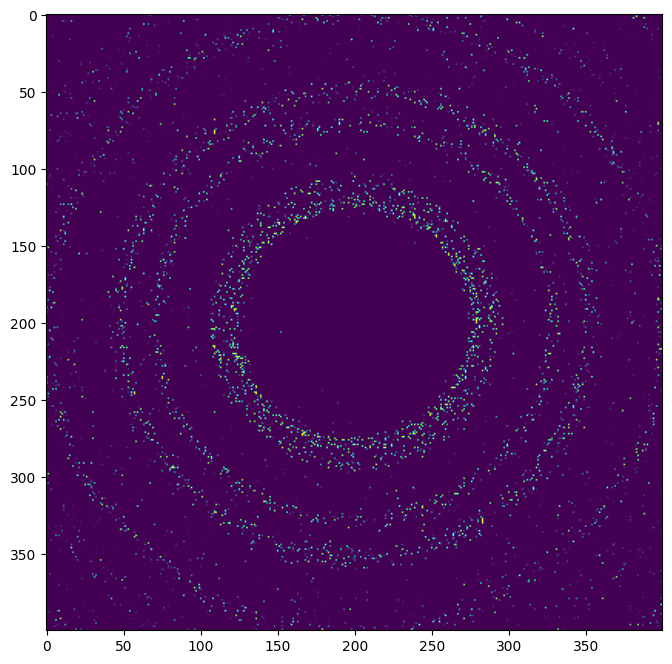

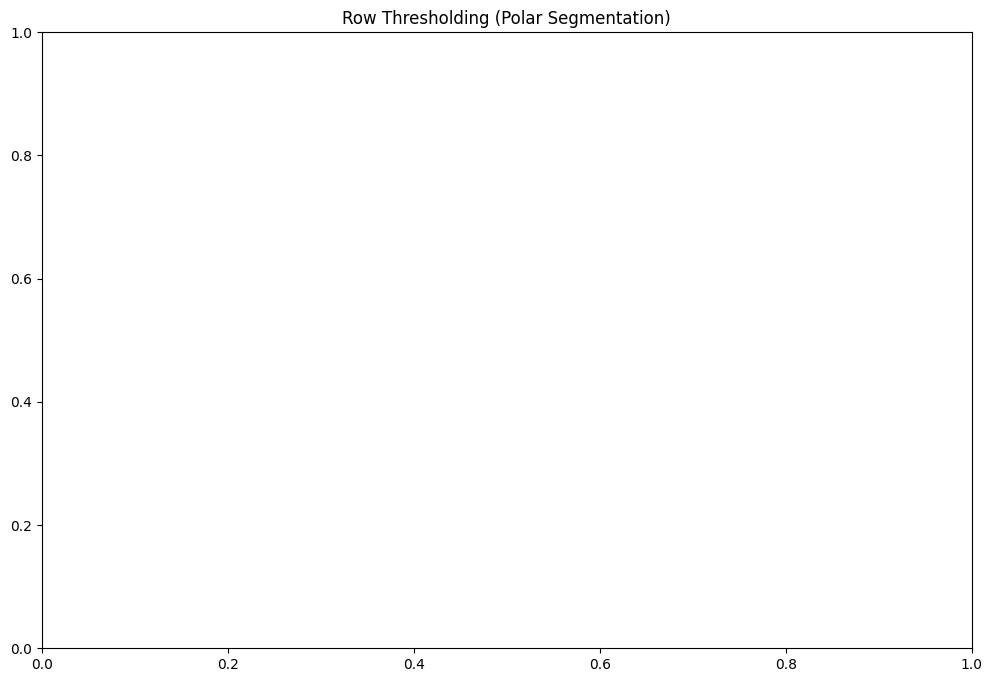

In [3]:
# Process
sum_data_row_threshold = sum_datafiles(
    SDATA, 
    DIFFIMAGES, 
    df_sum,
    method='Row_thresholding'
)

sd.io.Arrays.show(sum_data_row_threshold, icut=150)
plt.title('Row Thresholding (Polar Segmentation)')
plt.show()

### Visualizing Individual Processing Steps

To see intermediate results for debugging:

Initialized DiffractionPeakSegmenter with start_row=50, threshold_factor=5.5, center_radius=40, pre_mask_center=0px, angle_step=1.0, polar_radius=auto, min_blob_size=30, centroid_power=60
------------------------------
Starting Diffraction Peak Segmentation Process...
Input image size: 1024x1024
Calculated CoM at (520.76, 507.15). Applying shift (-9.26, 4.35).
Adaptive thresholding complete. Pixels masked in polar (r >= 50): 3938
Filtering Cartesian mask: Removing blobs smaller than 30 pixels...
Blob filtering kept 73 blobs (removed 36).

--- Entering Peak Concentration (using power-weighted CoM (p=60)) ---
Input mask shape: (1024, 1024), dtype: uint8, Num mask pixels: 13800
Input image shape: (1024, 1024), dtype: float64
ndimage.label found 73 blobs.
Calculating Sums using ndimage.sum_labels...
Calculated Sums for 73 labels.
First few Sums: [ 5033.15002324   282.69494722   504.73330166  4196.00515635
 15997.8921842 ]
Calculating power-weighted CoM (p=60) manually per blob...
Calculate

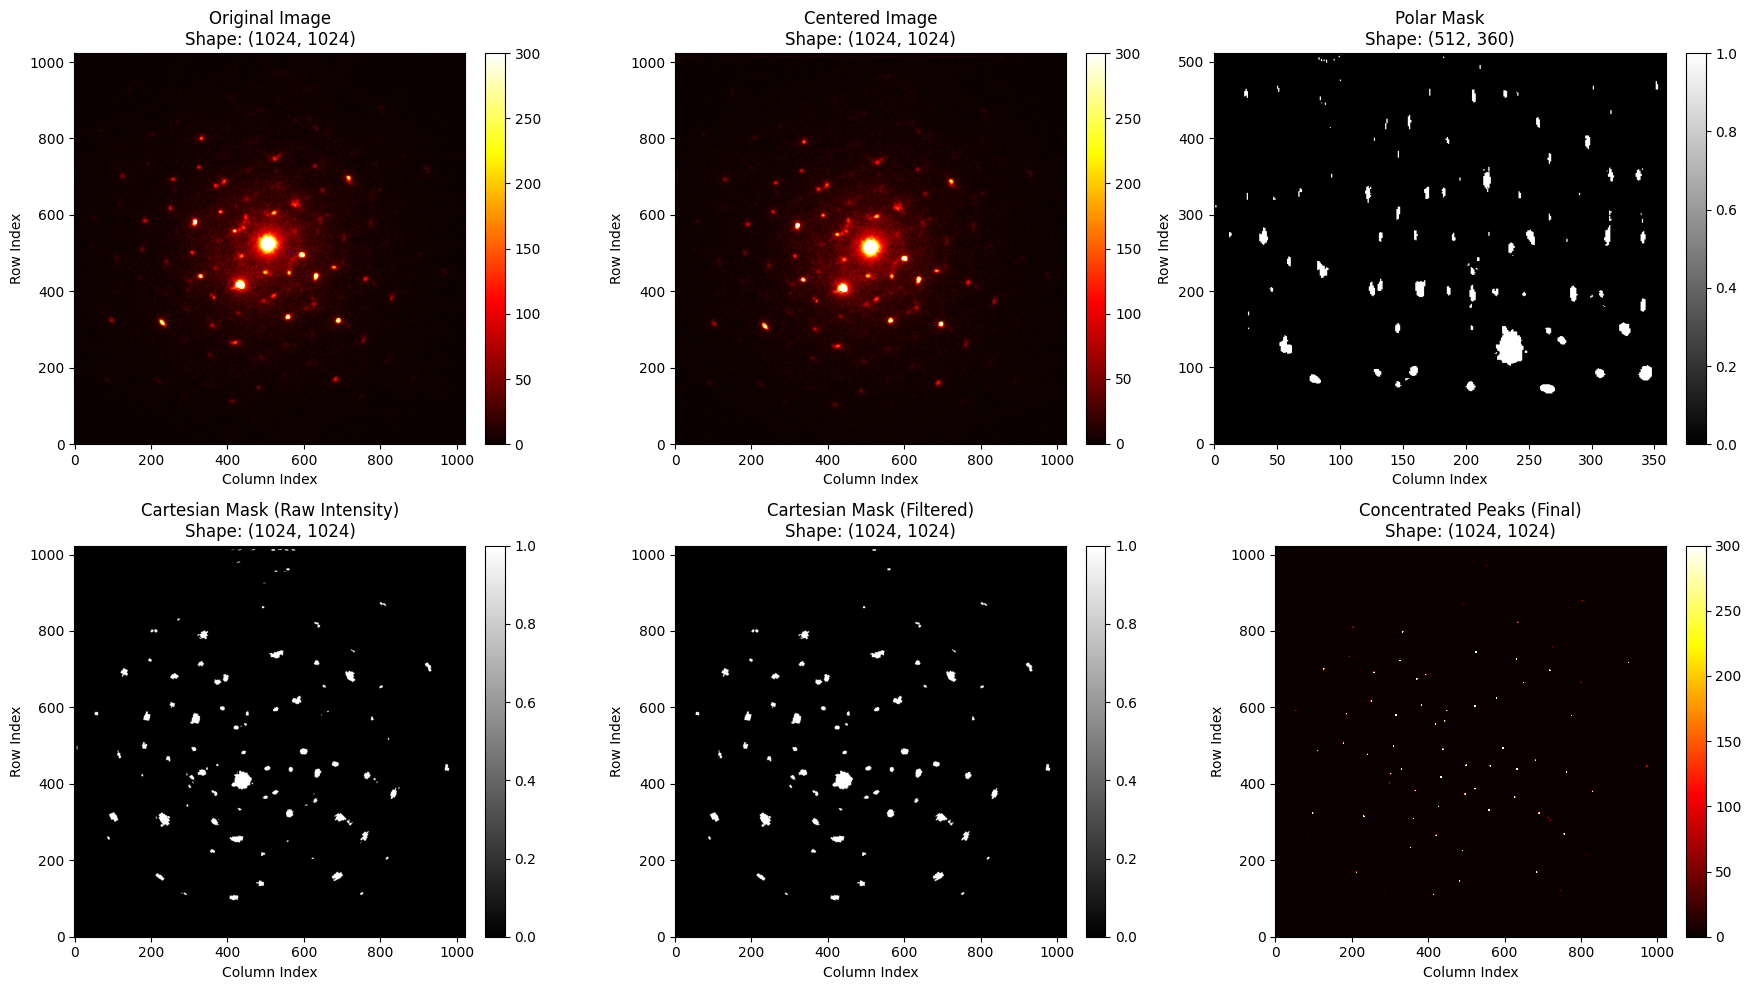

In [4]:
# Process a single test image with visualization
test_img_path = SDATA.data_dir.joinpath(df_sum.iloc[0].DatafileName)
test_img = sd.io.Datafiles.read(SDATA, test_img_path)
test_img = sd.io.Arrays.rescale(test_img, SDATA.detector.upscale, order=3)

# Enable verbose mode and show results
processor_debug = DiffractionPeakSegmenter(
    verbose=True,
    threshold_factor=5.5,
    start_row=50,
    center_radius=40,
    centroid_power=60
)

result = processor_debug.process_image(test_img, show_results=True)

## 7. Method 5: Blob Detection (Peak Finding)

**BEST OVERALL METHOD**

Uses blob detection algorithms to locate and integrate peak intensities.

### Detector Options:

| Detector | Description | Best For |
|----------|-------------|----------|
| `'doh'` | Determinant of Hessian | **RECOMMENDED** - Best results |
| `'log'` | Laplacian of Gaussian | Good alternative |
| `'mser'` | MSER (OpenCV) | Region-based |
| `'pcbr'` | Principal Curvature | Alternative approach |
| `'vote'` | Combines multiple detectors | Slower but robust |

### Background Subtraction Options:

| Method | Description | Best For |
|--------|-------------|----------|
| `'opening_downsampled'` | **RECOMMENDED** - Fast morphological opening | Most cases |
| `'opening'` | Full-resolution opening | High accuracy needed |
| `'gaussian'` | Gaussian blur | Smooth backgrounds |
| `'polynomial'` | Polynomial fit | Radial backgrounds |
| `'rolling_ball'` | Rolling ball algorithm | Variable backgrounds |

### Key Parameters:

**Detection:**
- `peak_min_sigma`: Minimum peak width (6-10 typical)
- `peak_max_sigma`: Maximum peak width (30-60 typical)
- `num_sigma_steps`: Detection resolution (20-30)
- `center_ignore_radius_pixels`: Exclude central peak region (40-70)

**Background:**
- `bg_disk_radius`: Morphological opening radius (60-80)
- `threshold_factor`: Peak threshold multiplier (3-4)

**Integration:**
- `integration_sigma_factor`: For LoG/DoH (2-4)
- `integration_fixed_radius`: For other methods (5-10)

Processing : 100%|██████████| 200/200 [02:03<00:00,  1.62it/s]



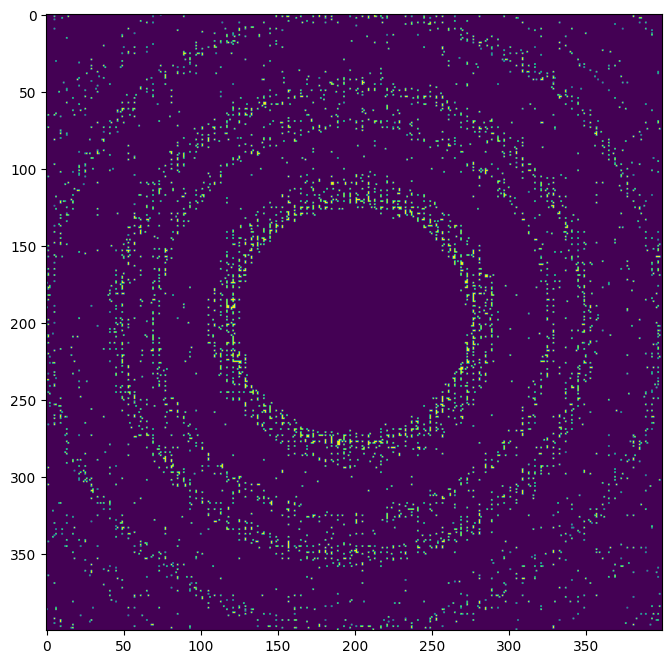

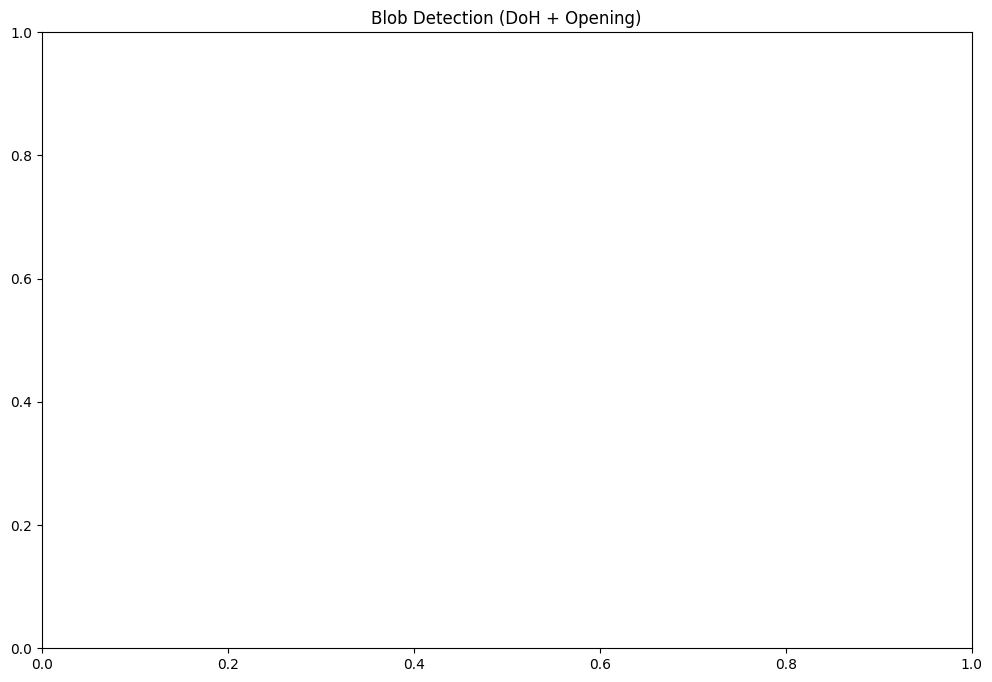

In [6]:
# === RECOMMENDED CONFIGURATION ===
processor_blob_detector = DiffractionPeakFinder(
    # Detector settings
    detector_method='doh',                    # Best performer
    background_method='opening_downsampled',  # Fast and effective
    
    # Peak detection parameters
    peak_min_sigma=10,
    peak_max_sigma=40,
    num_sigma_steps=20,
    
    # Background parameters
    bg_disk_radius=70,
    threshold_factor=3.5,
    
    # Integration parameters
    integration_sigma_factor=3,
    
    # Center exclusion
    center_ignore_radius_pixels=50,
    
    verbose=False  # Set True for detailed output
)

sum_data_blob = sum_datafiles(
    SDATA, 
    DIFFIMAGES, 
    df_sum,
    method='PeakFinding'
)

sd.io.Arrays.show(sum_data_blob, icut=150)
plt.title('Blob Detection (DoH + Opening)')
plt.show()

### Testing Different Detector Combinations

Try different configurations to find what works best for your data:

In [ ]:
# Configuration matrix for testing
configs = [
    {'detector': 'doh', 'background': 'opening_downsampled', 'name': 'DoH + Opening (BEST)'},
    {'detector': 'log', 'background': 'opening_downsampled', 'name': 'LoG + Opening'},
    {'detector': 'doh', 'background': 'polynomial', 'name': 'DoH + Polynomial'},
]

results = {}
for config in configs:
    print(f"\nTesting: {config['name']}")
    processor = DiffractionPeakFinder(
        detector_method=config['detector'],
        background_method=config['background'],
        peak_min_sigma=10,
        peak_max_sigma=40,
        bg_disk_radius=70,
        verbose=False
    )
    
    result = sum_datafiles(
        SDATA, DIFFIMAGES, df_sum,
        method='PeakFinding'
    )
    results[config['name']] = result

# Plot comparison
fig, axes = plt.subplots(1, len(configs), figsize=(15, 5))
for ax, (name, data) in zip(axes, results.items()):
    ax.imshow(data, cmap='hot', vmax=150)
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Debug Mode: Visualize Detection Process

DiffractionPeakFinder initialized:
  Detector: 'doh'
  Background: 'opening_downsampled'

--- Starting Image Processing (Detector: doh, Background: opening_downsampled) ---
Processing image of shape: (1024, 1024)
  Estimating background using method: 'opening_downsampled'...
Opening on downsampled (341, 341) with radius 23...
Upsampling background to (1024, 1024)...
Background estimation finished (0.37s)
  Estimating noise (MAD)... sigma=1.793 (0.03s)
DEBUG: Subtracted Image Stats: Min=0.00, Max=10942.99, Mean=6.39
  Detecting peaks using method: 'doh'...
      Running DoH on image downsampled by 4x
      DoH (downsampled) params: min_sig=2.50, max_sig=10.00, thresh=0.628 (NEEDS TUNING)
    Initial candidates found: 83 (2.00s)
  Filtering center (radius: 50 pixels)... 80 peaks remain after center filtering.
  Calculating integrated intensities for 80 peaks...
    Integrated intensity stats: Min=6649.6, Max=3944725.2, Mean=563856.3
DEBUG: Initial Peaks Found by _detect_peaks: 80
DEBUG: 

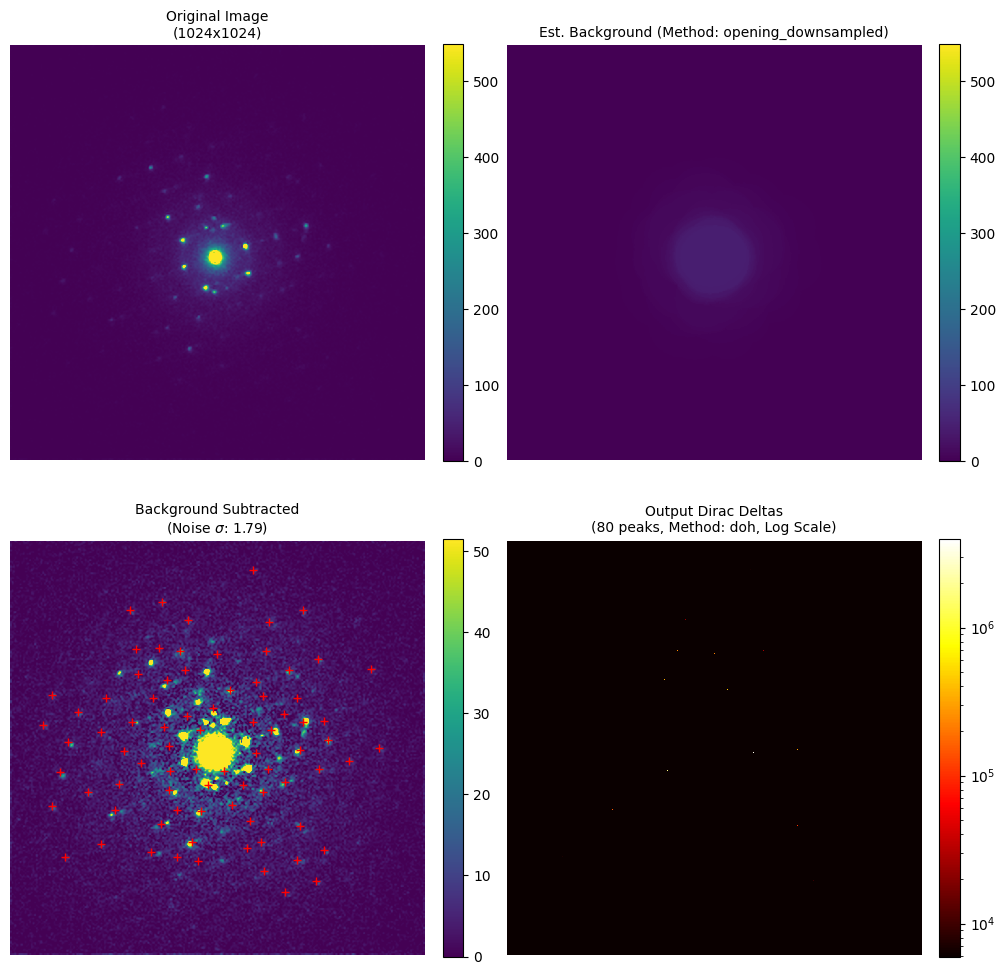


Detection Results:
  Found 80 peaks
  Noise sigma: 1.793
  Intensity range: 6649.6 - 3944725.2


In [7]:
# Process single image with full visualization
test_img_path = SDATA.data_dir.joinpath(df_sum.iloc[100].DatafileName)  # Pick a representative one
test_img = sd.io.Datafiles.read(SDATA, test_img_path)
test_img = sd.io.Arrays.rescale(test_img, SDATA.detector.upscale, order=3)

processor_debug = DiffractionPeakFinder(
    detector_method='doh',
    background_method='opening_downsampled',
    verbose=True,  # Print detailed info
    peak_min_sigma=10,
    peak_max_sigma=40
)

# Process and visualize
result = processor_debug.process_image(test_img, show_result=True)

print(f"\nDetection Results:")
print(f"  Found {len(processor_debug.last_peaks_data)} peaks")
print(f"  Noise sigma: {processor_debug.last_noise_sigma:.3f}")
if len(processor_debug.last_peaks_data) > 0:
    intensities = [p[2] for p in processor_debug.last_peaks_data]
    print(f"  Intensity range: {min(intensities):.1f} - {max(intensities):.1f}")

## 9. Comparison of All Methods

Let's compare the radial profiles of all methods:

In [ ]:
# Collect all results (modify based on what you've run)
comparison_data = [
    [sum_data_raw, 'k:', 'Raw Sum'],
    [sum_data_gmm, 'r:', 'GMM'],
    [sum_data_row_threshold, 'r-', 'Row Threshold'],
    [sum_data_blob, 'g-', 'Blob Detection (DoH)'],
]

# Add deconvolution if available
if 'sum_data_deconv' in locals():
    comparison_data.insert(1, [sum_data_deconv, 'k-', 'Deconvolution'])


# Plot radial profiles
ed.io.plot_radial_distributions(
    data_to_plot=comparison_data,
    xlimit=250,
    ylimit=220
)
plt.title('Comparison of Processing Methods')
plt.legend(loc='upper right')
plt.show()

### Side-by-Side Visual Comparison

In [ ]:
# Create figure with all methods
methods = [
    ('Raw', sum_data_raw, 300),
    ('GMM', sum_data_gmm, 150),
    ('Row Threshold', sum_data_row_threshold, 150),
    ('Blob (DoH)', sum_data_blob, 150),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.ravel()

for idx, (name, data, vmax) in enumerate(methods):
    im = axes[idx].imshow(data, cmap='hot', vmax=vmax)
    axes[idx].set_title(f'{name}\nMax: {np.max(data):.1f}', fontsize=12)
    axes[idx].axis('off')
    plt.colorbar(im, ax=axes[idx], fraction=0.046)

plt.suptitle('Method Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Saving Results

Save your processed diffraction patterns:

In [ ]:
# Save individual results
output_dir = r"C:\path\to\output"

# Example: Save blob detection result
sd.io.Arrays.save_as_image(
    sum_data_blob, 
    output_image=f'{output_dir}/result_blob_doh.png',
    itype='16bit'
)

# Save as numpy array for further processing
np.save(f'{output_dir}/result_blob_doh.npy', sum_data_blob)

print(f"Results saved to: {output_dir}")

## 11. Recommendations and Best Practices

### Quick Start Guide:

**For most datasets, try this order:**

1. **Start with Blob Detection (DoH)** - Usually gives best results
   ```python
   processor = DiffractionPeakFinder(
       detector_method='doh',
       background_method='opening_downsampled',
       peak_min_sigma=10,
       peak_max_sigma=40,
       bg_disk_radius=70
   )
   ```

2. **If DoH fails, try Row Thresholding** - More robust to noise
   ```python
   processor = DiffractionPeakSegmenter(
       threshold_factor=5.5,
       start_row=50,
       centroid_power=60
   )
   ```

3. **For low SNR data, try GMM** - More forgiving

### Parameter Tuning Tips:

**Blob Detection:**
- If too many false positives: Increase `threshold_factor` (3 → 4)
- If missing peaks: Decrease `threshold_factor` (3.5 → 3)
- For large peaks: Increase `peak_max_sigma` (40 → 60)
- For small peaks: Decrease `peak_min_sigma` (10 → 6)

**Row Thresholding:**
- If too sensitive: Increase `threshold_factor` (5.5 → 7)
- If missing peaks: Decrease `threshold_factor` (5.5 → 4)
- For noisy data: Increase `centroid_power` (60 → 100)
- Adjust `start_row` to just exclude central peak

### Common Issues:

| Problem | Solution |
|---------|----------|
| Central peak artifacts | Increase `center_ignore_radius` or `start_row` |
| Too many noise peaks | Increase `threshold_factor` or `min_blob_size` |
| Missing weak peaks | Decrease `threshold_factor`, increase `peak_max_sigma` |
| Slow processing | Use downsampled methods or reduce `num_sigma_steps` |
| Ring patterns | Row Thresholding works especially well |

### Performance Notes:

**Speed ranking (fastest to slowest):**
1. Raw Sum
2. GMM
3. Row Thresholding
4. Blob Detection (with downsampling)
5. UNet (GPU)
6. Richardson-Lucy Deconvolution

**Quality ranking (based on development):**
1. Blob Detection (DoH + Opening) 
2. Row Thresholding 
3. GMM
4. Deconvolution
5. Raw Sum

## 12. Advanced: Custom Processing Pipeline

You can create your own processing pipeline:

In [ ]:
def custom_processing_pipeline(SDATA, DIFFIMAGES, df_sum):
    """
    Example custom pipeline:
    1. Try Blob Detection (DoH)
    2. If fails, fall back to Row Thresholding
    3. Apply custom post-processing
    """
    
    # Try primary method
    try:
        print("Attempting Blob Detection (DoH)...")
        processor = DiffractionPeakFinder(
            detector_method='doh',
            background_method='opening_downsampled',
            peak_min_sigma=10,
            peak_max_sigma=40
        )
        result = sum_datafiles(
            SDATA, DIFFIMAGES, df_sum,
            method='PeakFinding',
            processor=processor
        )
        
        # Check quality
        if np.max(result) > 100:  # Simple quality check
            print("✓ Primary method succeeded")
            return result
        else:
            raise ValueError("Low quality output")
            
    except Exception as e:
        print(f"Primary method failed: {e}")
        print("Falling back to Row Thresholding...")
        
        # Fallback method
        processor = DiffractionPeakSegmenter(
            threshold_factor=5.5,
            start_row=50,
            centroid_power=60
        )
        result = sum_datafiles(
            SDATA, DIFFIMAGES, df_sum,
            method='Row_thresholding',
            processor=processor
        )
        print("✓ Fallback method succeeded")
        return result

# Run custom pipeline
final_result = custom_processing_pipeline(SDATA, DIFFIMAGES, df_sum)
sd.io.Arrays.show(final_result, icut=150)
plt.title('Custom Pipeline Result')
plt.show()

## Summary

This notebook demonstrated different methods for processing 4D-STEM diffraction data:

1. **Blob Detection (DoH)** - Best overall quality
2. **Row Thresholding** - Fast and robust alternative
3. **GMM** - Good baseline, no tuning required
4. **Deconvolution** - Traditional approach, slower
5. **UNet** - Promising but requires training
6. **Raw Sum** - Baseline comparison

### Next Steps:

1. Try the recommended methods on your data
2. Compare radial profiles with theoretical patterns
3. Fine-tune parameters based on your specific dataset
4. Use the best method in your production pipeline

### Further Reading:

- Check `utilities.py` for detailed parameter documentation
- See `sum_datafiles.py` for method implementations


